# Mapping Analysis 📌🪢📌
`Assumption Made`: 
1. We assume that the *source* given for the *target* is already a correct source to create a good analogy
2. I am hypothesizing the best way to create an analogy is 
    1. Find the Domain (personalization)
    2. Find the Target properties
    3. Find the Best source, that best maps the properties

`Our Question or Goal here?`
1. Property Extraction Accuracy (can the model extract the right attributes from target/source?)
    - How accurate can the models extract the needed properties of Target? (no description)
    - How accurate can the models extract the needed properties of Target? (with description)
    => Check how many words are the same, Needs some NLP here to clean the data

2. Mapping Accuracy (given two property sets, can it correctly align them?)
    - Can Model find the properties and then map them to given properties?
        - Given the Target + properties, can the model find the properies from source that maps correctly? (no description)
        - Given the Target + properties, can the model find the properies from source that maps correctly? (with description)

    - Can Model find the properties and then map them to given properties?
        - Given the Target + properties, and Source + properties, Can the model correctly match them?(no description)
        - Given the Target + properties, and Source + properties, Can the model correctly match them?(with description)

In [75]:
import os
from dotenv import load_dotenv
import pandas as pd
load_dotenv()
# Import the easy LLM importer
from easy_llm_importer import create_client, list_available_models, quick_chat, DSPyAdapter
import dspy
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
deepinfra_api_key = os.getenv("DEEPINFRA_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

# Create client
client = create_client()

In [76]:
# Import the easy LLM importer
from easy_llm_importer import create_client, list_available_models, quick_chat

# See all available models
models = list_available_models()
print(f"Available models ({len(models)}):\n")
for model in models:
    print(f"  • {model}")

Available models (11):

  • gpt-oss-20b
  • gpt-oss-120b
  • gpt-4.1-mini
  • gpt-4.1-nano
  • grok-4-fast
  • gemini-2.5-flash-lite
  • meta-llama-3-1-70b-instruct
  • meta-llama-3-1-8b-instruct
  • deepseek-r1
  • qwen3-14b
  • qwen3-32b


In [77]:
import json, ast, re, time, random
import pandas as pd
import numpy as np

# ---------- parsing & normalization ----------
def try_to_list(x):
    if isinstance(x, list): return x
    if x is None or (isinstance(x, float) and np.isnan(x)): return []
    s = str(x).strip()
    try:
        return json.loads(s)
    except Exception:
        try:
            return ast.literal_eval(s)
        except Exception:
            return []

def try_to_dict(x):
    if isinstance(x, dict): return x
    if x is None or (isinstance(x, float) and np.isnan(x)): return {}
    s = str(x).strip()
    try:
        obj = json.loads(s)
    except Exception:
        try:
            obj = ast.literal_eval(s)
        except Exception:
            return {}
    return obj if isinstance(obj, dict) else {}

def norm(t):
    t = str(t).lower().strip()
    t = t.replace("\u2011","-").replace("\u2013","-").replace("\u2014","-")
    return re.sub(r"\s+", " ", t)

# ---------- safe counts ----------
def set_count(xs):      return len({norm(x) for x in try_to_list(xs)})
def set_intersection(a,b):
    A = {norm(x) for x in try_to_list(a)}
    B = {norm(x) for x in try_to_list(b)}
    return len(A & B)

# ---------- retry/backoff for model calls (drop-in) ----------
def with_backoff(call_fn, max_retries=6, base=0.5):
    for i in range(max_retries):
        try:
            return call_fn()
        except Exception as e:
            if i == max_retries - 1:
                raise
            sleep = base * (2**i) + random.random()*0.2
            time.sleep(sleep)


In [78]:
import json, ast, pandas as pd, numpy as np

def to_list(x):
    if isinstance(x, list): return x
    if x is None or (isinstance(x, float) and np.isnan(x)): return []
    s = str(x).strip()
    try:    return json.loads(s)         # works if it's valid JSON
    except: 
        try: return ast.literal_eval(s)  # safe parse for Python-literals
        except: return []                # fallback

### DSPy Signature Classes for Analogy Mapping Analysis

Below are the signature classes organized by the research questions:
1. **Property Extraction Accuracy** - Can models extract properties correctly?
2. **Mapping Accuracy** - Can models align properties correctly?

Each has variants with/without descriptions to test the impact of additional context.


In [79]:
"""
===========================================
1. PROPERTY EXTRACTION ACCURACY SIGNATURES
===========================================
Test: Can the model extract the right attributes from target/source?
"""

# 1A: Extract properties WITHOUT description
class PropertyExtraction(dspy.Signature):
    """Extract key properties and attributes from a scientific concept."""
    
    concept: str = dspy.InputField(desc="The scientific concept to analyze")
    properties: list[str] = dspy.OutputField(desc="List of key properties (One to three words each)")


# 1B: Extract properties WITH description  
class PropertyExtractionWithDescription(dspy.Signature):
    """Extract key properties and attributes from a scientific concept with contextual description."""
    
    concept: str = dspy.InputField(desc="The scientific concept to analyze")
    description: str = dspy.InputField(desc="Detailed description or context about the concept")
    properties: list[str] = dspy.OutputField(desc="List of key properties (One to three words each)")


"""
===========================================
2. MAPPING ACCURACY SIGNATURES
===========================================
Test: Can the model correctly align properties between source and target?
"""

# 2A: Find and map source properties to target (WITHOUT description)
class SourcePropertyMapping(dspy.Signature):
    """Given a target concept with its properties, find corresponding properties from a source concept that map correctly."""
    
    target_concept: str = dspy.InputField(desc="The target concept being explained")
    target_properties: list[str] = dspy.InputField(desc="Known properties of the target concept")
    source_concept: str = dspy.InputField(desc="The source concept used for analogy")
    mapped_source_properties: list[str] = dspy.OutputField(desc="Properties from source that map to each target property")


# 2B: Find and map source properties to target (WITH description)
class SourcePropertyMappingWithDescription(dspy.Signature):
    """Given a target concept with its properties and descriptions, find corresponding properties from a source concept."""
    
    target_concept: str = dspy.InputField(desc="The target concept being explained")
    target_description: str = dspy.InputField(desc="Description of the target concept")
    target_properties: list[str] = dspy.InputField(desc="Known properties of the target concept")
    source_concept: str = dspy.InputField(desc="The source concept used for analogy")
    source_description: str = dspy.InputField(desc="Description of the source concept")
    mapped_source_properties: list[str] = dspy.OutputField(desc="Properties from source that map to each target property, in the same order")


# 2C: Match given property sets (WITHOUT description)
class PropertyMatching(dspy.Signature):
    """Given both target and source properties, create the correct mappings between them."""
    
    target_concept: str = dspy.InputField(desc="The target concept")
    target_properties: list[str] = dspy.InputField(desc="Properties of the target concept")
    source_concept: str = dspy.InputField(desc="The source concept")
    source_properties: list[str] = dspy.InputField(desc="Properties of the source concept")
    property_mappings: dict[str, str] = dspy.OutputField(desc="Dictionary mapping target properties to source properties")


# 2D: Match given property sets (WITH description)
class PropertyMatchingWithDescription(dspy.Signature):
    """Given both target and source properties with descriptions, create accurate mappings."""
    
    target_concept: str = dspy.InputField(desc="The target concept")
    target_description: str = dspy.InputField(desc="Description of the target concept")
    target_properties: list[str] = dspy.InputField(desc="Properties of the target concept")
    source_concept: str = dspy.InputField(desc="The source concept")
    source_description: str = dspy.InputField(desc="Description of the source concept")  
    source_properties: list[str] = dspy.InputField(desc="Properties of the source concept")
    property_mappings: dict[str, str] = dspy.OutputField(desc="Dictionary mapping target properties to source properties with reasoning")
    #mapping_rationale: str = dspy.OutputField(desc="Explanation of why these mappings are appropriate")




#### Example Usage: Property Extraction Accuracy

Testing how well models can extract properties from concepts.


In [80]:
adapter = DSPyAdapter(client, model_name="gpt-4.1-nano")
lm = adapter.get_dspy_lm()
dspy.settings.configure(lm=lm)
print("✅ DSPy LM Configured!")

✅ DSPy LM Configured!


In [81]:
# Example 1A: Property Extraction WITHOUT Description
print("="*60)
print("Example 1A: Property Extraction (No Description)")
print("="*60)

extractor = dspy.ChainOfThought(PropertyExtraction)
result = extractor(concept="Atomic structure")

print(f"\nConcept: Atomic structure")
print(f"\nExtracted Properties:")
for i, prop in enumerate(result.properties, 1):
    print(f"  {i}. {prop}")
print(f"\nReasoning: {result.reasoning}")


Example 1A: Property Extraction (No Description)



Concept: Atomic structure

Extracted Properties:
  1. subatomic particles
  2. nucleus
  3. electron cloud
  4. protons
  5. neutrons
  6. electrons
  7. atomic number
  8. mass number
  9. isotopes
  10. electron configuration

Reasoning: The atomic structure refers to the arrangement of subatomic particles within an atom, primarily consisting of protons, neutrons, and electrons. It explains how these particles are organized, how they interact, and how they determine the atom's properties. Understanding atomic structure involves concepts such as atomic number, mass number, electron configuration, and nuclear composition, which are fundamental to chemistry and physics.


In [82]:
# Example 1B: Property Extraction WITH Description
print("="*60)
print("Example 1B: Property Extraction (With Description)")
print("="*60)

extractor_desc = dspy.ChainOfThought(PropertyExtractionWithDescription)
description = "An atom consists of a nucleus containing protons and neutrons, with electrons orbiting in shells around it. The electrons are held by electromagnetic force."
result = extractor_desc(
    concept="Atomic structure",
    description=description
)

print(f"\nConcept: Atomic structure")
print(f"\nDescription provided: {description[:100]}...")
print(f"\nExtracted Properties:")
for i, prop in enumerate(result.properties, 1):
    print(f"  {i}. {prop}")
print(f"\nReasoning: {result.reasoning}")


Example 1B: Property Extraction (With Description)

Concept: Atomic structure

Description provided: An atom consists of a nucleus containing protons and neutrons, with electrons orbiting in shells aro...

Extracted Properties:
  1. nucleus
  2. electrons
  3. electromagnetic force
  4. protons
  5. neutrons
  6. electron shells

Reasoning: The atomic structure is characterized by a central nucleus composed of protons and neutrons, which defines the atom's identity and mass. Electrons orbit the nucleus in specific energy levels or shells, held in place by electromagnetic forces. This arrangement determines the atom's chemical properties, reactivity, and behavior in different environments. The key properties include the composition of the nucleus, the arrangement of electrons, and the forces that hold these particles together.


#### Example Usage: Source Property Mapping

Testing if models can find source properties that map to given target properties.


In [83]:
# Example 2A: Source Property Mapping WITHOUT Description
print("="*60)
print("Example 2A: Source Property Mapping (No Description)")
print("="*60)

mapper = dspy.ChainOfThought(SourcePropertyMapping)

# Store inputs in variables
target_props = ["Central massive body", "Orbiting smaller objects", "Force holding system together"]

result = mapper(
    target_concept="Atomic structure",
    target_properties=target_props,
    source_concept="Solar system"
)

print(f"\nTarget: Atomic structure")
print(f"Target Properties: {target_props}")  # Use the variable
print(f"\nSource: Solar system")
print(f"\nMapped Source Properties:")
for i, (target_prop, source_prop) in enumerate(zip(target_props, result.mapped_source_properties), 1):  # Use the variable
    print(f"  {i}. {target_prop} ↔ {source_prop}")
print(f"\nReasoning: {result.reasoning}")


Example 2A: Source Property Mapping (No Description)

Target: Atomic structure
Target Properties: ['Central massive body', 'Orbiting smaller objects', 'Force holding system together']

Source: Solar system

Mapped Source Properties:
  1. Central massive body ↔ Central massive body" -> "Sun
  2. Orbiting smaller objects ↔ Orbiting smaller objects" -> "Planets
  3. Force holding system together ↔ Force holding system together" -> "Gravity

Reasoning: The atomic structure consists of a central nucleus (massive body), with electrons orbiting around it, and the electromagnetic force holding the system together. Similarly, the solar system has the Sun as the central massive body, planets orbiting it, and gravity as the force maintaining the system's cohesion. The analogy maps the nucleus to the Sun, electrons to planets, and electromagnetic force to gravity, aligning the properties across both systems.


In [84]:
# Example 2B: Source Property Mapping WITH Description
print("="*60)
print("Example 2B: Source Property Mapping (With Description)")
print("="*60)

mapper_desc = dspy.ChainOfThought(SourcePropertyMappingWithDescription)

# Store inputs in variables
target_concept = "Atomic structure"
target_props = ["Central massive body", "Orbiting smaller objects", "Force holding system together"]
source_concept = "Solar system"

result = mapper_desc(
    target_concept=target_concept,
    target_description="An atom has a nucleus with protons and neutrons at the center, and electrons orbit around it in shells.",
    target_properties=target_props,
    source_concept=source_concept,
    source_description="The solar system has the Sun at the center with planets orbiting around it due to gravitational force."
)

print(f"\nTarget: {target_concept}")  # Use variable
print(f"Source: {source_concept}")  # Use variable
print(f"\nProperty Mappings:")
for i, (target_prop, source_prop) in enumerate(zip(target_props, result.mapped_source_properties), 1):  # Use variable
    print(f"  {i}. {target_prop} ↔ {source_prop}")
print(f"\nReasoning: {result.reasoning}")


Example 2B: Source Property Mapping (With Description)

Target: Atomic structure
Source: Solar system

Property Mappings:
  1. Central massive body ↔ Central massive body
  2. Orbiting smaller objects ↔ Orbiting smaller objects
  3. Force holding system together ↔ Force holding system together

Reasoning: The atomic structure and the solar system both consist of a central massive body around which smaller objects orbit. In an atom, the nucleus (containing protons and neutrons) acts as the central massive body, with electrons orbiting around it in shells. Similarly, in the solar system, the Sun is the central massive body, with planets orbiting around it due to gravitational force. The force holding the system together in both cases is the electromagnetic force in the atom and gravity in the solar system. Therefore, the properties correspond as follows: the nucleus corresponds to the Sun, electrons correspond to planets, and the forces are electromagnetic and gravitational respectively,

#### Example Usage: Property Matching

Testing if models can correctly match pre-given property sets from target and source.


In [85]:
# Example 2C: Property Matching WITHOUT Description
print("="*60)
print("Example 2C: Property Matching (No Description)")
print("="*60)

matcher = dspy.ChainOfThought(PropertyMatching)

# Store inputs in variables
target_concept = "Atomic structure"
source_concept = "Solar system"

result = matcher(
    target_concept=target_concept,
    target_properties=["Nucleus", "Electrons", "Electromagnetic force", "Energy levels"],
    source_concept=source_concept,
    source_properties=["Sun", "Planets", "Gravitational force", "Orbital distances"]
)

print(f"\nTarget: {target_concept}")  # Use variable
print(f"Source: {source_concept}")  # Use variable
print(f"\nProperty Mappings:")
for target_prop, source_prop in result.property_mappings.items():
    print(f"  • {target_prop} ↔ {source_prop}")
print(f"\nReasoning: {result.reasoning}")

Example 2C: Property Matching (No Description)

Target: Atomic structure
Source: Solar system

Property Mappings:
  • Nucleus ↔ Sun
  • Electrons ↔ Planets
  • Electromagnetic force ↔ Gravitational force
  • Energy levels ↔ Orbital distances

Reasoning: The atomic structure involves a nucleus, electrons, electromagnetic forces, and energy levels, which are fundamental components of an atom. The solar system consists of the Sun, planets, gravitational forces, and orbital distances. Both systems are structured around a central body exerting a force (electromagnetic in atoms, gravitational in the solar system) that governs the behavior of surrounding objects (electrons or planets). The energy levels in atoms can be loosely compared to orbital distances in the solar system, as both describe the spatial arrangement of components around a central body. Therefore, the nucleus corresponds to the Sun, electrons correspond to planets, electromagnetic force corresponds to gravitational force, and

In [86]:
# Example 2D: Property Matching WITH Description
print("="*60)
print("Example 2D: Property Matching (With Description)")
print("="*60)

matcher_desc = dspy.ChainOfThought(PropertyMatchingWithDescription)

# Store inputs in variables
target_concept = "Atomic structure"
source_concept = "Solar system"

result = matcher_desc(
    target_concept=target_concept,
    target_description="An atom consists of a dense nucleus containing protons and neutrons, with electrons moving in orbital shells around it, held by electromagnetic attraction.",
    target_properties=["Nucleus", "Electrons", "Electromagnetic force", "Energy levels"],
    source_concept=source_concept,
    source_description="The solar system consists of the Sun at the center with planets orbiting around it in elliptical paths, held by gravitational force.",
    source_properties=["Sun", "Planets", "Gravitational force", "Orbital distances"]
)

print(f"\nTarget: {target_concept}")  # Use variable
print(f"Source: {source_concept}")  # Use variable
print(f"\nProperty Mappings:")
for target_prop, source_prop in result.property_mappings.items():
    print(f"  • {target_prop} ↔ {source_prop}")
print(f"\nReasoning: {result.reasoning}")

Example 2D: Property Matching (With Description)

Target: Atomic structure
Source: Solar system

Property Mappings:
  • Nucleus ↔ Sun
  • Electrons ↔ Planets
  • Electromagnetic force ↔ Gravitational force
  • Energy levels ↔ Orbital distances

Reasoning: The atomic structure involves a nucleus and electrons, with electromagnetic force governing their interactions and energy levels defining electron shells. In the solar system, the Sun and planets are held in orbit by gravitational force, with orbital distances describing their positions. The nucleus in an atom is analogous to the Sun in the solar system as the central body exerting a force that keeps other components in orbit or bound. Electrons are akin to planets orbiting the nucleus, both moving around a central mass. The electromagnetic force in atomic structure is comparable to the gravitational force in the solar system, as both are fundamental forces that govern the interactions and stability of the systems. Energy levels in at

## Load the data and process on it

In [87]:
df_scar = pd.read_csv('../../data/SCAR_cleaned_manually.csv')

df_scar.head()

,id,system_a,system_b,system_a_domain,system_b_domain,system_a_background,system_b_background,mappings_parsed,mapping_count,explanation_parsed,explanation_count,system_a_bg_wc,system_b_bg_wc
0,1,biological clock,clock,Biology,Engineering,The biological clock is a fundamental aspect o...,"A clock, also known as a timepiece, is a devic...","[['changes', 'pointer'], ['state', 'time'], ['...",3,['Changes correspond to pointers: In the biolo...,3,190,118
1,2,Biosphere,Library,Biology,Art,The biosphere refers to the sum of all ecosyst...,A library is much more than a building full of...,"[['biology', 'books'], ['biodiversity', 'Book ...",3,"[""Biology corresponds to books: In the biosphe...",3,110,149
2,3,Respiratory system,engine,Biology,Physics,The respiratory system is a critical biologica...,An engine or motor is a machine that transform...,"[['oxygen', 'fuel'], ['the lungs', 'combustion...",3,['Oxygen corresponds to fuel: In the respirato...,3,131,143
3,4,Spread of Pathogens,Spread of Fire,Biology,Physics,"The spread of pathogens is a serious concern, ...",Fire is a natural process that is essential fo...,"[['pathogen', 'fire'], ['crowd', 'combustibles...",3,['Pathogens correspond to fire: in the transmi...,3,127,170
4,5,Gene editing,kirigami,Biology,Art,Gene editing is a revolutionary technique in m...,Kirigami is a fascinating art form that origin...,"[['Gene', 'raw material'], ['CRISPR-Cas9 Techn...",3,['Gene corresponds to raw materials: in gene e...,3,133,130


In [88]:
# ========================================================
# TRIAL EXPERIMENT: Run All Signatures on All Models
# ========================================================

import os
import json
from datetime import datetime
from tqdm.auto import tqdm
import time
import numpy as np

# Create results directory
results_dir = './results'
os.makedirs(results_dir, exist_ok=True)

# Get 5 random examples
np.random.seed(42)  # For reproducibility
sample_df = df_scar.sample(n=2, random_state=42).reset_index(drop=True)

print("="*70)
print("EXPERIMENT CONFIGURATION")
print("="*70)
print(f"Dataset: SCAR")
print(f"Sample Size: {len(sample_df)} examples")
print(f"Models: {len(list_available_models())} models")
print(f"Signatures: 6 (1A, 1B, 2A, 2B, 2C, 2D)")
print(f"Results Directory: {results_dir}")
print("="*70)

# Display sampled examples
print("\n📋 Sampled Examples:")
for idx, row in sample_df.iterrows():
    print(f"  {idx+1}. {row['system_a']} ↔ {row['system_b']}")

# Get all available models
available_models = list_available_models()

EXPERIMENT CONFIGURATION
Dataset: SCAR
Sample Size: 2 examples
Models: 11 models
Signatures: 6 (1A, 1B, 2A, 2B, 2C, 2D)
Results Directory: ./results

📋 Sampled Examples:
  1. Westernization Movement ↔ Reform Movement of 1898
  2. household ↔ government


In [89]:
# ========================================================
# EXPERIMENT 1A: Property Extraction (No Description)
# ========================================================

def run_experiment_1a(models=None, df=None, results_dir="./results"):
    """
    Extract properties of system_a (target concept) WITHOUT descriptions.
    Computes metrics on UNIQUE, NORMALIZED sets (fair comparison).
    """
    assert df is not None, "Pass the dataframe as df=sample_df"
    assert models is not None, "Pass your fixed 6-model list as models=[...]"

    results = []
    print("\n" + "="*70)
    print("EXPERIMENT 1A: Property Extraction (No Description)")
    print("="*70)

    for model_name in models:
        # Configure model (keep your adapter; just ensure temp/top_p/max_tokens are fixed upstream)
        try:
            adapter = DSPyAdapter(client, model_name=model_name)
            lm = adapter.get_dspy_lm()          # make sure this uses same decoding params for all models
            dspy.settings.configure(lm=lm)
            predictor = dspy.ChainOfThought(PropertyExtraction)
        except Exception as e:
            print(f"❌ Failed to load {model_name}: {e}")
            continue

        for idx, row in df.iterrows():
            try:
                start_time = time.time()
                out = predictor(concept=row["system_a"])   # DSPy module call
                elapsed = time.time() - start_time

                # --------- Ground truth (from mappings_parsed) ----------
                pairs = to_list(row.get("mappings_parsed"))
                gt_list = [m[0] for m in pairs if isinstance(m, (list, tuple)) and len(m) >= 1]
                gt_set  = {norm(x) for x in gt_list}

                # --------- Predictions ----------
                pred_raw = getattr(out, "properties", [])
                pred_list = to_list(pred_raw)              # tolerate strings
                pred_set  = {norm(x) for x in pred_list}   # unique + normalized

                # --------- Metrics on sets ----------
                inter = pred_set & gt_set
                precision = len(inter) / len(pred_set) if pred_set else 0.0
                recall    = len(inter) / len(gt_set) if gt_set else 0.0
                f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0

                # --------- Record ---------
                results.append({
                    "example_id": row["id"],
                    "model": model_name,
                    "target_concept": row["system_a"],
                    "source_concept": row["system_b"],

                    # keep both raw and normalized for transparency
                    "predicted_properties_raw": json.dumps(pred_list, ensure_ascii=False),
                    "ground_truth_properties_raw": json.dumps(gt_list, ensure_ascii=False),
                    "predicted_properties": json.dumps(sorted(pred_set), ensure_ascii=False),
                    "ground_truth_properties": json.dumps(sorted(gt_set), ensure_ascii=False),

                    # counts must reflect UNIQUE, NORMALIZED sets
                    "num_predicted": len(pred_set),
                    "num_ground_truth": len(gt_set),
                    "num_matched": len(inter),

                    "precision": round(precision, 3),
                    "recall": round(recall, 3),
                    "f1_score": round(f1, 3),

                    "reasoning": getattr(out, "reasoning", None),
                    "elapsed_time": round(elapsed, 2),
                })

            except Exception as e:
                results.append({
                    "example_id": row.get("id"),
                    "model": model_name,
                    "target_concept": row.get("system_a"),
                    "source_concept": row.get("system_b"),
                    "error": str(e),
                })

    # --------- Save + sanity check ----------
    df_results = pd.DataFrame(results)
    output_file = f"{results_dir}/1a_property_extraction_no_desc.csv"
    df_results.to_csv(output_file, index=False)
    print(f"✅ Saved: {output_file}")

    # immediate consistency check (catches silent bugs)
    chk = df_results.copy()
    # re-count based on the normalized fields we just saved
    chk["num_predicted_chk"] = chk["predicted_properties"].apply(lambda s: len({norm(x) for x in to_list(s)}))
    chk["num_ground_truth_chk"] = chk["ground_truth_properties"].apply(lambda s: len({norm(x) for x in to_list(s)}))
    assert (chk["num_predicted_chk"] == chk["num_predicted"]).all(), "num_predicted mismatch after save"
    assert (chk["num_ground_truth_chk"] == chk["num_ground_truth"]).all(), "num_ground_truth mismatch after save"

    return df_results


In [90]:
# ========================================================
# EXPERIMENT 1A: Property Extraction (No Description)
# ========================================================

def run_experiment_1a():
    """Extract properties from target concept without description"""
    results = []
    
    print("\n" + "="*70)
    print("EXPERIMENT 1A: Property Extraction (No Description)")
    print("="*70)
    
    for model_name in tqdm(available_models, desc="Models"):
        # Configure model
        try:
            adapter = DSPyAdapter(client, model_name=model_name)
            lm = adapter.get_dspy_lm()
            dspy.settings.configure(lm=lm)
            predictor = dspy.ChainOfThought(PropertyExtraction)
        except Exception as e:
            print(f"❌ Failed to load {model_name}: {e}")
            continue
        
        for idx, row in sample_df.iterrows():
            try:
                start_time = time.time()
                result = predictor(concept=row['system_a'])
                elapsed_time = time.time() - start_time
                
                # Parse ground truth properties from mappings
                ground_truth = [m[0] for m in eval(row['mappings_parsed'])]
                predicted = [p.lower().strip() for p in result.properties]
                gt_set = set([p.lower().strip() for p in ground_truth])
                pred_set = set(predicted)
                
                intersection = gt_set & pred_set
                precision = len(intersection) / len(pred_set) if pred_set else 0
                recall = len(intersection) / len(gt_set) if gt_set else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'predicted_properties': json.dumps(result.properties),
                    'ground_truth_properties': json.dumps(ground_truth),
                    'num_predicted': len(predicted),
                    'num_ground_truth': len(gt_set),
                    'num_matched': len(intersection),
                    'precision': round(precision, 3),
                    'recall': round(recall, 3),
                    'f1_score': round(f1, 3),
                    'reasoning': result.reasoning,
                    'elapsed_time': round(elapsed_time, 2)
                })
            except Exception as e:
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'error': str(e)
                })
    
    df_results = pd.DataFrame(results)
    output_file = f'{results_dir}/1a_property_extraction_no_desc.csv'
    df_results.to_csv(output_file, index=False)
    print(f"✅ Saved: {output_file}")
    return df_results

In [91]:
# ========================================================
# EXPERIMENT 1B: Property Extraction (With Description)
# ========================================================

def run_experiment_1b():
    """Extract properties from target concept with description"""
    results = []
    
    print("\n" + "="*70)
    print("EXPERIMENT 1B: Property Extraction (With Description)")
    print("="*70)
    
    for model_name in tqdm(available_models, desc="Models"):
        try:
            adapter = DSPyAdapter(client, model_name=model_name)
            lm = adapter.get_dspy_lm()
            dspy.settings.configure(lm=lm)
            predictor = dspy.ChainOfThought(PropertyExtractionWithDescription)
        except Exception as e:
            print(f"❌ Failed to load {model_name}: {e}")
            continue
        
        for idx, row in sample_df.iterrows():
            try:
                start_time = time.time()
                result = predictor(
                    concept=row['system_a'],
                    description=row['system_a_background']
                )
                elapsed_time = time.time() - start_time
                
                ground_truth = [m[0] for m in eval(row['mappings_parsed'])]
                predicted = [p.lower().strip() for p in result.properties]
                gt_set = set([p.lower().strip() for p in ground_truth])
                pred_set = set(predicted)
                
                intersection = gt_set & pred_set
                precision = len(intersection) / len(pred_set) if pred_set else 0
                recall = len(intersection) / len(gt_set) if gt_set else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
                
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'predicted_properties': json.dumps(result.properties),
                    'ground_truth_properties': json.dumps(ground_truth),
                    'num_predicted': len(predicted),
                    'num_ground_truth': len(gt_set),
                    'num_matched': len(intersection),
                    'precision': round(precision, 3),
                    'recall': round(recall, 3),
                    'f1_score': round(f1, 3),
                    'reasoning': result.reasoning,
                    'elapsed_time': round(elapsed_time, 2)
                })
            except Exception as e:
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'error': str(e)
                })
    
    df_results = pd.DataFrame(results)
    output_file = f'{results_dir}/1b_property_extraction_with_desc.csv'
    df_results.to_csv(output_file, index=False)
    print(f"✅ Saved: {output_file}")
    return df_results

In [ ]:
# ========================================================
# EXPERIMENT 2A: Source Property Mapping (No Description)
# ========================================================

def run_experiment_2a():
    """Find source properties that map to target properties"""
    results = []
    
    print("\n" + "="*70)
    print("EXPERIMENT 2A: Source Property Mapping (No Description)")
    print("="*70)
    
    for model_name in tqdm(available_models, desc="Models"):
        try:
            adapter = DSPyAdapter(client, model_name=model_name)
            lm = adapter.get_dspy_lm()
            dspy.settings.configure(lm=lm)
            predictor = dspy.ChainOfThought(SourcePropertyMapping)
        except Exception as e:
            print(f"❌ Failed to load {model_name}: {e}")
            continue
        
        for idx, row in sample_df.iterrows():
            try:
                mappings = eval(row['mappings_parsed'])
                target_props = [m[0] for m in mappings]
                ground_truth_source = [m[1] for m in mappings]
                
                start_time = time.time()
                result = predictor(
                    target_concept=row['system_a'],
                    target_properties=target_props,
                    source_concept=row['system_b']
                )
                elapsed_time = time.time() - start_time
                
                # Calculate accuracy
                correct = 0
                for pred, gt in zip(result.mapped_source_properties, ground_truth_source):
                    if pred.lower().strip() == gt.lower().strip():
                        correct += 1
                
                accuracy = correct / len(ground_truth_source) if ground_truth_source else 0
                
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'target_properties': json.dumps(target_props),
                    'predicted_source_properties': json.dumps(result.mapped_source_properties),
                    'ground_truth_source_properties': json.dumps(ground_truth_source),
                    'num_correct': correct,
                    'total': len(ground_truth_source),
                    'accuracy': round(accuracy, 3),
                    'reasoning': result.reasoning,
                    'elapsed_time': round(elapsed_time, 2)
                })
            except Exception as e:
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'error': str(e)
                })
    
    df_results = pd.DataFrame(results)
    output_file = f'{results_dir}/2a_source_mapping_no_desc.csv'
    df_results.to_csv(output_file, index=False)
    print(f"✅ Saved: {output_file}")
    return df_results



In [92]:
# ========================================================
# EXPERIMENT 2B: Source Property Mapping (With Description)
# ========================================================

def run_experiment_2b():
    """Find source properties with descriptions"""
    results = []
    
    print("\n" + "="*70)
    print("EXPERIMENT 2B: Source Property Mapping (With Description)")
    print("="*70)
    
    for model_name in tqdm(available_models, desc="Models"):
        try:
            adapter = DSPyAdapter(client, model_name=model_name)
            lm = adapter.get_dspy_lm()
            dspy.settings.configure(lm=lm)
            predictor = dspy.ChainOfThought(SourcePropertyMappingWithDescription)
        except Exception as e:
            print(f"❌ Failed to load {model_name}: {e}")
            continue
        
        for idx, row in sample_df.iterrows():
            try:
                mappings = eval(row['mappings_parsed'])
                target_props = [m[0] for m in mappings]
                ground_truth_source = [m[1] for m in mappings]
                
                start_time = time.time()
                result = predictor(
                    target_concept=row['system_a'],
                    target_description=row['system_a_background'],
                    target_properties=target_props,
                    source_concept=row['system_b'],
                    source_description=row['system_b_background']
                )
                elapsed_time = time.time() - start_time
                
                correct = 0
                for pred, gt in zip(result.mapped_source_properties, ground_truth_source):
                    if pred.lower().strip() == gt.lower().strip():
                        correct += 1
                
                accuracy = correct / len(ground_truth_source) if ground_truth_source else 0
                
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'target_properties': json.dumps(target_props),
                    'predicted_source_properties': json.dumps(result.mapped_source_properties),
                    'ground_truth_source_properties': json.dumps(ground_truth_source),
                    'num_correct': correct,
                    'total': len(ground_truth_source),
                    'accuracy': round(accuracy, 3),
                    'reasoning': result.reasoning,
                    'elapsed_time': round(elapsed_time, 2)
                })
            except Exception as e:
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'error': str(e)
                })
    
    df_results = pd.DataFrame(results)
    output_file = f'{results_dir}/2b_source_mapping_with_desc.csv'
    df_results.to_csv(output_file, index=False)
    print(f"✅ Saved: {output_file}")
    return df_results



In [93]:
# ========================================================
# EXPERIMENT 2C: Property Matching (No Description)
# ========================================================

def run_experiment_2c():
    """Match given property sets without description"""
    results = []
    
    print("\n" + "="*70)
    print("EXPERIMENT 2C: Property Matching (No Description)")
    print("="*70)
    
    for model_name in tqdm(available_models, desc="Models"):
        try:
            adapter = DSPyAdapter(client, model_name=model_name)
            lm = adapter.get_dspy_lm()
            dspy.settings.configure(lm=lm)
            predictor = dspy.ChainOfThought(PropertyMatching)
        except Exception as e:
            print(f"❌ Failed to load {model_name}: {e}")
            continue
        
        for idx, row in sample_df.iterrows():
            try:
                mappings = eval(row['mappings_parsed'])
                target_props = [m[0] for m in mappings]
                source_props = [m[1] for m in mappings]
                ground_truth_dict = {m[0]: m[1] for m in mappings}
                
                start_time = time.time()
                result = predictor(
                    target_concept=row['system_a'],
                    target_properties=target_props,
                    source_concept=row['system_b'],
                    source_properties=source_props
                )
                elapsed_time = time.time() - start_time
                
                # Calculate accuracy
                correct = sum(1 for k, v in result.property_mappings.items() 
                             if ground_truth_dict.get(k, "").lower() == v.lower())
                accuracy = correct / len(ground_truth_dict) if ground_truth_dict else 0
                
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'predicted_mappings': json.dumps(result.property_mappings),
                    'ground_truth_mappings': json.dumps(ground_truth_dict),
                    'num_correct': correct,
                    'total': len(ground_truth_dict),
                    'accuracy': round(accuracy, 3),
                    'reasoning': result.reasoning,
                    'elapsed_time': round(elapsed_time, 2)
                })
            except Exception as e:
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'error': str(e)
                })
    
    df_results = pd.DataFrame(results)
    output_file = f'{results_dir}/2c_property_matching_no_desc.csv'
    df_results.to_csv(output_file, index=False)
    print(f"✅ Saved: {output_file}")
    return df_results

In [94]:
# ========================================================
# EXPERIMENT 2D: Property Matching (With Description)
# ========================================================

def run_experiment_2d():
    """Match given property sets with description"""
    results = []
    
    print("\n" + "="*70)
    print("EXPERIMENT 2D: Property Matching (With Description)")
    print("="*70)
    
    for model_name in tqdm(available_models, desc="Models"):
        try:
            adapter = DSPyAdapter(client, model_name=model_name)
            lm = adapter.get_dspy_lm()
            dspy.settings.configure(lm=lm)
            predictor = dspy.ChainOfThought(PropertyMatchingWithDescription)
        except Exception as e:
            print(f"❌ Failed to load {model_name}: {e}")
            continue
        
        for idx, row in sample_df.iterrows():
            try:
                mappings = eval(row['mappings_parsed'])
                target_props = [m[0] for m in mappings]
                source_props = [m[1] for m in mappings]
                ground_truth_dict = {m[0]: m[1] for m in mappings}
                
                start_time = time.time()
                result = predictor(
                    target_concept=row['system_a'],
                    target_description=row['system_a_background'],
                    target_properties=target_props,
                    source_concept=row['system_b'],
                    source_description=row['system_b_background'],
                    source_properties=source_props
                )
                elapsed_time = time.time() - start_time
                
                correct = sum(1 for k, v in result.property_mappings.items() 
                             if ground_truth_dict.get(k, "").lower() == v.lower())
                accuracy = correct / len(ground_truth_dict) if ground_truth_dict else 0
                
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'predicted_mappings': json.dumps(result.property_mappings),
                    'ground_truth_mappings': json.dumps(ground_truth_dict),
                    'num_correct': correct,
                    'total': len(ground_truth_dict),
                    'accuracy': round(accuracy, 3),
                    'reasoning': result.reasoning,
                    'elapsed_time': round(elapsed_time, 2)
                })
            except Exception as e:
                results.append({
                    'example_id': row['id'],
                    'model': model_name,
                    'target_concept': row['system_a'],
                    'source_concept': row['system_b'],
                    'error': str(e)
                })
    
    df_results = pd.DataFrame(results)
    output_file = f'{results_dir}/2d_property_matching_with_desc.csv'
    df_results.to_csv(output_file, index=False)
    print(f"✅ Saved: {output_file}")
    return df_results


In [95]:
# ========================================================
# TRIAL EXPERIMENT: Run All Signatures on All Models
# ========================================================

import os
import json
from datetime import datetime
from tqdm.auto import tqdm
import time
import numpy as np

# Create results directory
results_dir = './results'
os.makedirs(results_dir, exist_ok=True)

# Get 5 random examples
np.random.seed(42)  # For reproducibility
sample_df = df_scar.sample(n=50, random_state=42).reset_index(drop=True)

print("="*70)
print("EXPERIMENT CONFIGURATION")
print("="*70)
print(f"Dataset: SCAR")
print(f"Sample Size: {len(sample_df)} examples")
print(f"Models: {len(list_available_models())} models")
print(f"Signatures: 6 (1A, 1B, 2A, 2B, 2C, 2D)")
print(f"Results Directory: {results_dir}")
print("="*70)

# Display sampled examples
print("\n📋 Sampled Examples:")
for idx, row in sample_df.iterrows():
    print(f"  {idx+1}. {row['system_a']} ↔ {row['system_b']}")

# Get all available models
available_models = list_available_models()

EXPERIMENT CONFIGURATION
Dataset: SCAR
Sample Size: 50 examples
Models: 11 models
Signatures: 6 (1A, 1B, 2A, 2B, 2C, 2D)
Results Directory: ./results

📋 Sampled Examples:
  1. Westernization Movement ↔ Reform Movement of 1898
  2. household ↔ government
  3. Cell division ↔ the replicator
  4. Westernization Movement ↔ The Revolution of 1911
  5. Electrochemical Reaction ↔ Power Generation
  6. Limit Modification System ↔ Firewall
  7. Article ↔ River
  8. Crystals ↔ Architecture
  9. money ↔ time
  10. Deep Learning ↔ The Brain
  11. Ecosystem ↔ Machines
  12. Sound Wave Propagation ↔ Water Wave Propagation
  13. The Evolution of Viruses ↔ The Production Line of a Car Factory
  14. Alveoli ↔ Balloons
  15. hard drive ↔ book
  16. Microbiome ↔ ecosystem
  17. slope ↔ career
  18. Tight-Bind Approximation ↔ Taylor Expansion
  19. Buddhism ↔ Islam
  20. Lattice ↔ Rubik's Cube
  21. Disability of the plant ↔ cocoon
  22. Platelets ↔ Construction Workers
  23. Turbine Engine ↔ Heart
  24. 

In [ ]:
# ========================================================
# RUN ALL EXPERIMENTS
# ========================================================

start_time = time.time()
base_df = sample_df
MODELS_ANALOGY = list_available_models()
results_1a = run_experiment_1a()
results_1b = run_experiment_1b()
results_2a = run_experiment_2a()
results_2b = run_experiment_2b()
results_2c = run_experiment_2c()
results_2d = run_experiment_2d()

total_time = time.time() - start_time

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED!")
print("="*70)
print(f"Total Time: {total_time/60:.1f} minutes")
print(f"Results saved in: {results_dir}/")
print("Files created:")
for fn in [
    "1a_property_extraction_no_desc.csv",
    "1b_property_extraction_with_desc.csv",
    "2a_source_mapping_no_desc.csv",
    "2b_source_mapping_with_desc.csv",
    "2c_property_matching_no_desc.csv",
    "2d_property_matching_with_desc.csv",
]:
    print(f"   • {fn}")
print("="*70)


EXPERIMENT 1A: Property Extraction (No Description)


Models: 100%|██████████| 11/11 [52:59<00:00, 289.06s/it] 


✅ Saved: ./results/1a_property_extraction_no_desc.csv

EXPERIMENT 1B: Property Extraction (With Description)


Models: 100%|██████████| 11/11 [1:10:08<00:00, 382.61s/it]

✅ Saved: ./results/1b_property_extraction_with_desc.csv


AssertionError: 

In [ ]:
# ========================================================
# COMPREHENSIVE VISUALIZATION ANALYSIS
# ========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set publication-quality style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Load all results
results_dir = Path('./results')

data = {}
files = {
    '1a': '1a_property_extraction_no_desc.csv',
    '1b': '1b_property_extraction_with_desc.csv',
    '2a': '2a_source_mapping_no_desc.csv',
    '2b': '2b_source_mapping_with_desc.csv',
    '2c': '2c_property_matching_no_desc.csv',
    '2d': '2d_property_matching_with_desc.csv'
}

for key, filename in files.items():
    filepath = results_dir / filename
    if filepath.exists():
        data[key] = pd.read_csv(filepath)
        # Remove rows with errors
        if 'error' in data[key].columns:
            data[key] = data[key][data[key]['error'].isna()].copy()
        print(f"✅ Loaded {key}: {len(data[key])} valid rows")
    else:
        print(f"⚠️ Missing: {filename}")

print(f"\n📊 Ready to visualize {len(data)} experiment results!")

✅ Loaded 1a: 11 valid rows
✅ Loaded 1b: 11 valid rows
✅ Loaded 2a: 11 valid rows
✅ Loaded 2b: 11 valid rows
✅ Loaded 2c: 11 valid rows
✅ Loaded 2d: 11 valid rows

📊 Ready to visualize 6 experiment results!


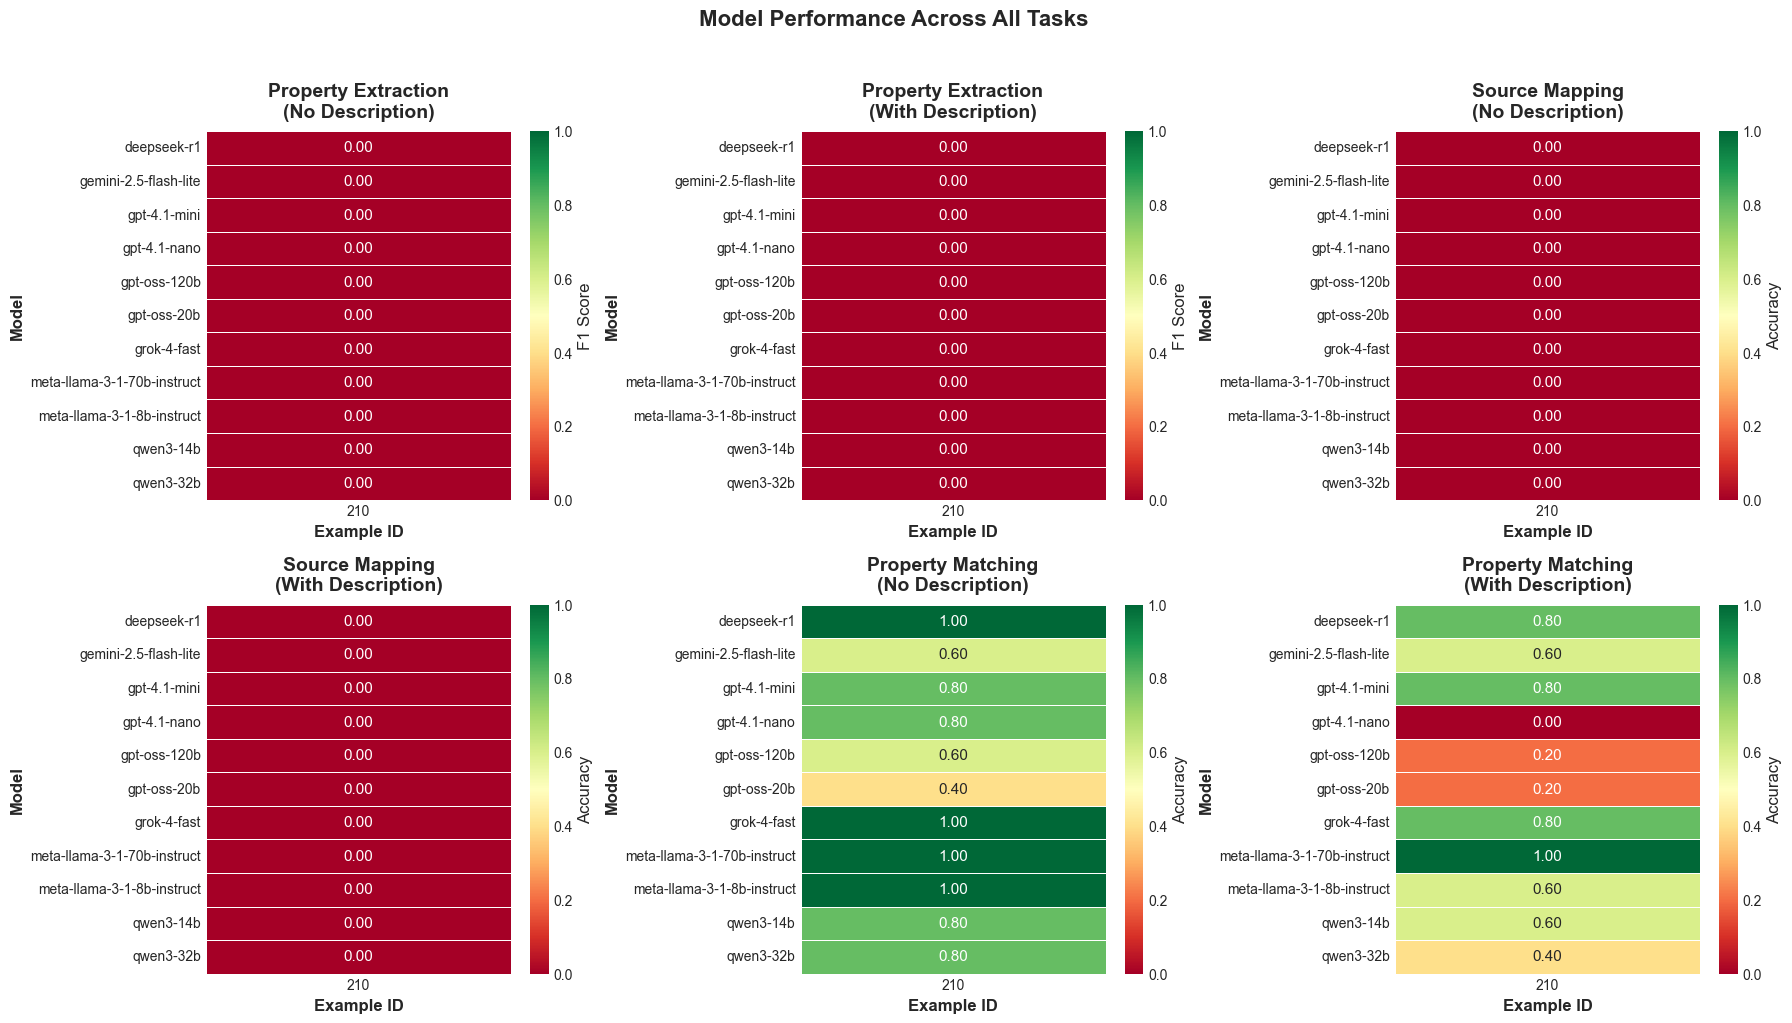

In [ ]:
# ========================================================
# VISUALIZATION 1: Overall Model Performance Heatmap
# ========================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Across All Tasks', fontsize=16, fontweight='bold', y=1.02)

task_names = {
    '1a': 'Property Extraction\n(No Description)',
    '1b': 'Property Extraction\n(With Description)',
    '2a': 'Source Mapping\n(No Description)',
    '2b': 'Source Mapping\n(With Description)',
    '2c': 'Property Matching\n(No Description)',
    '2d': 'Property Matching\n(With Description)'
}

for idx, (task_key, task_name) in enumerate(task_names.items()):
    ax = axes[idx // 3, idx % 3]
    
    if task_key in data:
        df = data[task_key]
        
        # Get the appropriate metric
        if task_key in ['1a', '1b']:
            metric = 'f1_score'
            vmax = 1.0
        else:
            metric = 'accuracy'
            vmax = 1.0
        
        # Create pivot table for heatmap
        pivot = df.pivot_table(
            values=metric, 
            index='model', 
            columns='example_id', 
            aggfunc='mean'
        )
        
        # Create heatmap
        sns.heatmap(
            pivot, 
            ax=ax, 
            cmap='RdYlGn', 
            annot=True, 
            fmt='.2f',
            vmin=0, 
            vmax=vmax,
            cbar_kws={'label': metric.replace('_', ' ').title()},
            linewidths=0.5
        )
        
        ax.set_title(task_name, fontweight='bold', pad=10)
        ax.set_xlabel('Example ID', fontweight='bold')
        ax.set_ylabel('Model', fontweight='bold')
        ax.tick_params(axis='y', rotation=0)
    else:
        ax.text(0.5, 0.5, 'Data Not Available', 
                ha='center', va='center', fontsize=14, color='gray')
        ax.set_title(task_name, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig(results_dir / 'viz_1_performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

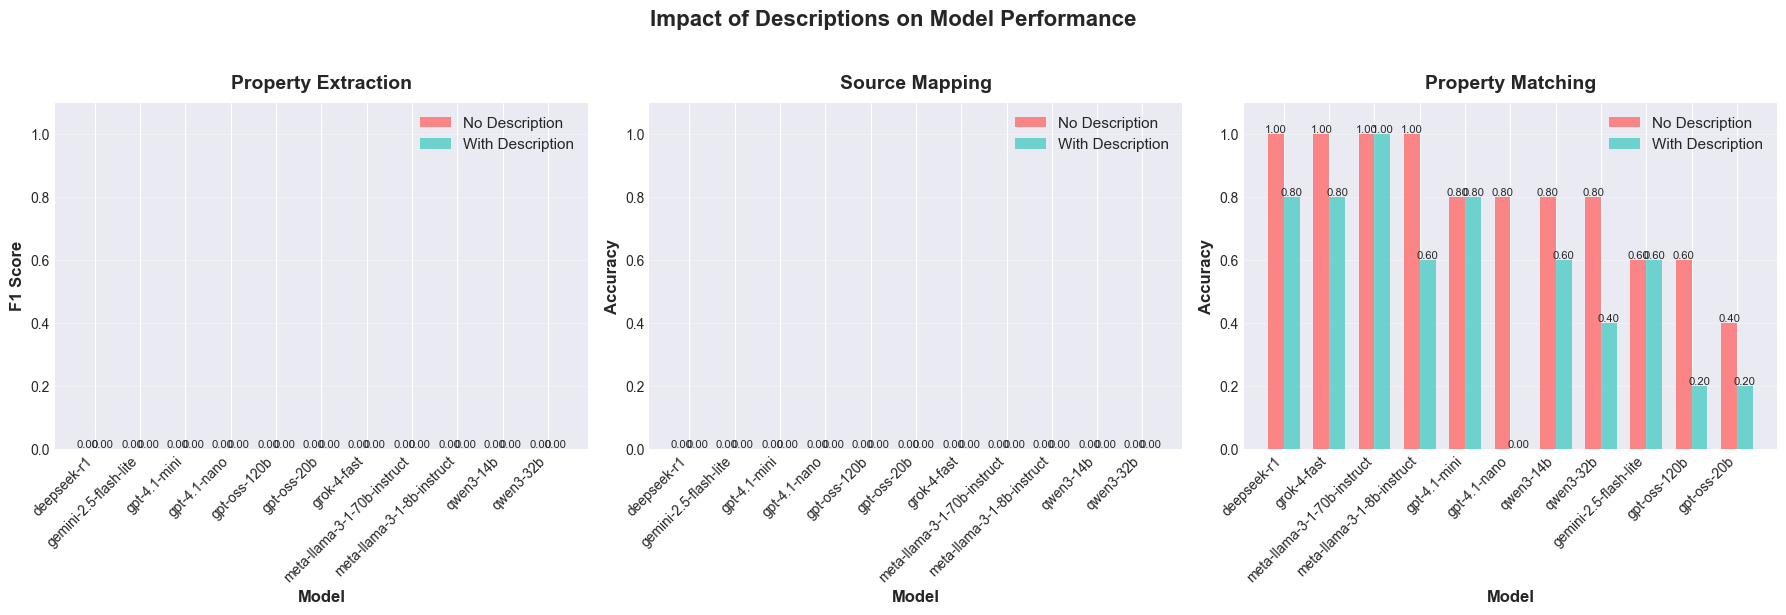

In [ ]:
# ========================================================
# VISUALIZATION 2: With vs Without Description Comparison
# ========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Impact of Descriptions on Model Performance', fontsize=16, fontweight='bold', y=1.02)

comparisons = [
    ('1a', '1b', 'Property Extraction', 'f1_score'),
    ('2a', '2b', 'Source Mapping', 'accuracy'),
    ('2c', '2d', 'Property Matching', 'accuracy')
]

for idx, (no_desc_key, with_desc_key, task_name, metric) in enumerate(comparisons):
    ax = axes[idx]
    
    if no_desc_key in data and with_desc_key in data:
        # Aggregate by model
        no_desc = data[no_desc_key].groupby('model')[metric].mean().sort_values(ascending=False)
        with_desc = data[with_desc_key].groupby('model')[metric].mean()
        
        # Align models
        models = no_desc.index
        x = np.arange(len(models))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, no_desc.values, width, label='No Description', alpha=0.8, color='#FF6B6B')
        bars2 = ax.bar(x + width/2, with_desc[models].values, width, label='With Description', alpha=0.8, color='#4ECDC4')
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}',
                       ha='center', va='bottom', fontsize=8)
        
        ax.set_xlabel('Model', fontweight='bold')
        ax.set_ylabel(metric.replace('_', ' ').title(), fontweight='bold')
        ax.set_title(task_name, fontweight='bold', pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.legend(loc='upper right')
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 1.1)
    else:
        ax.text(0.5, 0.5, 'Data Not Available', 
                ha='center', va='center', fontsize=14, color='gray')
        ax.set_title(task_name, fontweight='bold')

plt.tight_layout()
plt.savefig(results_dir / 'viz_2_description_impact.png', dpi=300, bbox_inches='tight')
plt.show()


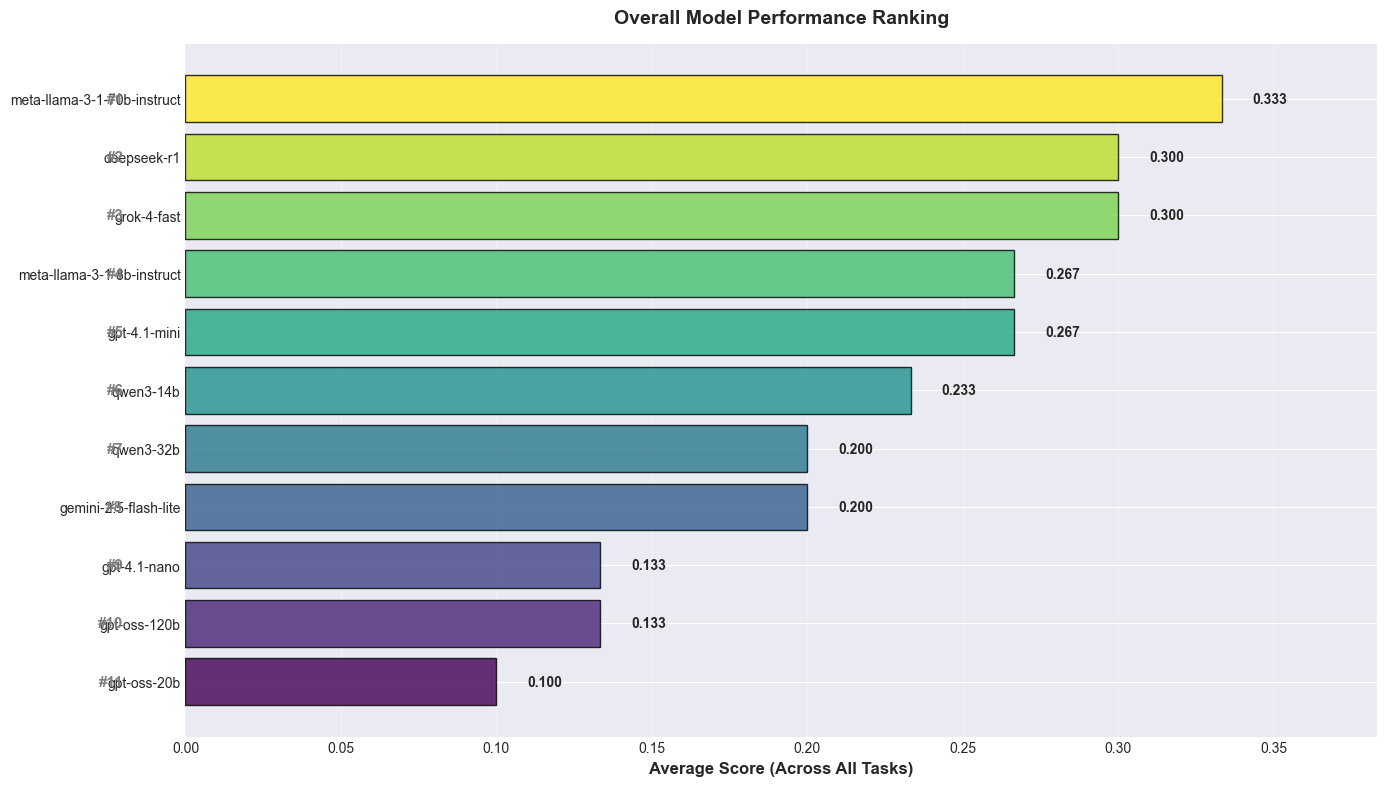

In [ ]:

# ========================================================
# VISUALIZATION 3: Model Rankings Across Tasks
# ========================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Collect all model scores
model_scores = {}

for task_key, df in data.items():
    metric = 'f1_score' if task_key in ['1a', '1b'] else 'accuracy'
    
    for model in df['model'].unique():
        if model not in model_scores:
            model_scores[model] = {}
        
        score = df[df['model'] == model][metric].mean()
        model_scores[model][task_key] = score

# Create DataFrame
scores_df = pd.DataFrame(model_scores).T
scores_df['average'] = scores_df.mean(axis=1)
scores_df = scores_df.sort_values('average', ascending=True)

# Create horizontal bar chart
y_pos = np.arange(len(scores_df))
colors = plt.cm.viridis(np.linspace(0, 1, len(scores_df)))

bars = ax.barh(y_pos, scores_df['average'], color=colors, alpha=0.8, edgecolor='black')

# Add value labels
for i, (idx, row) in enumerate(scores_df.iterrows()):
    ax.text(row['average'] + 0.01, i, f"{row['average']:.3f}", 
            va='center', fontweight='bold', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(scores_df.index)
ax.set_xlabel('Average Score (Across All Tasks)', fontweight='bold', fontsize=12)
ax.set_title('Overall Model Performance Ranking', fontweight='bold', fontsize=14, pad=15)
ax.set_xlim(0, max(scores_df['average']) * 1.15)
ax.grid(axis='x', alpha=0.3)

# Add ranking numbers
for i, (idx, row) in enumerate(scores_df.iterrows()):
    ax.text(-0.02, i, f"#{len(scores_df)-i}", 
            ha='right', va='center', fontweight='bold', fontsize=11, color='gray')

plt.tight_layout()
plt.savefig(results_dir / 'viz_3_model_rankings.png', dpi=300, bbox_inches='tight')
plt.show()

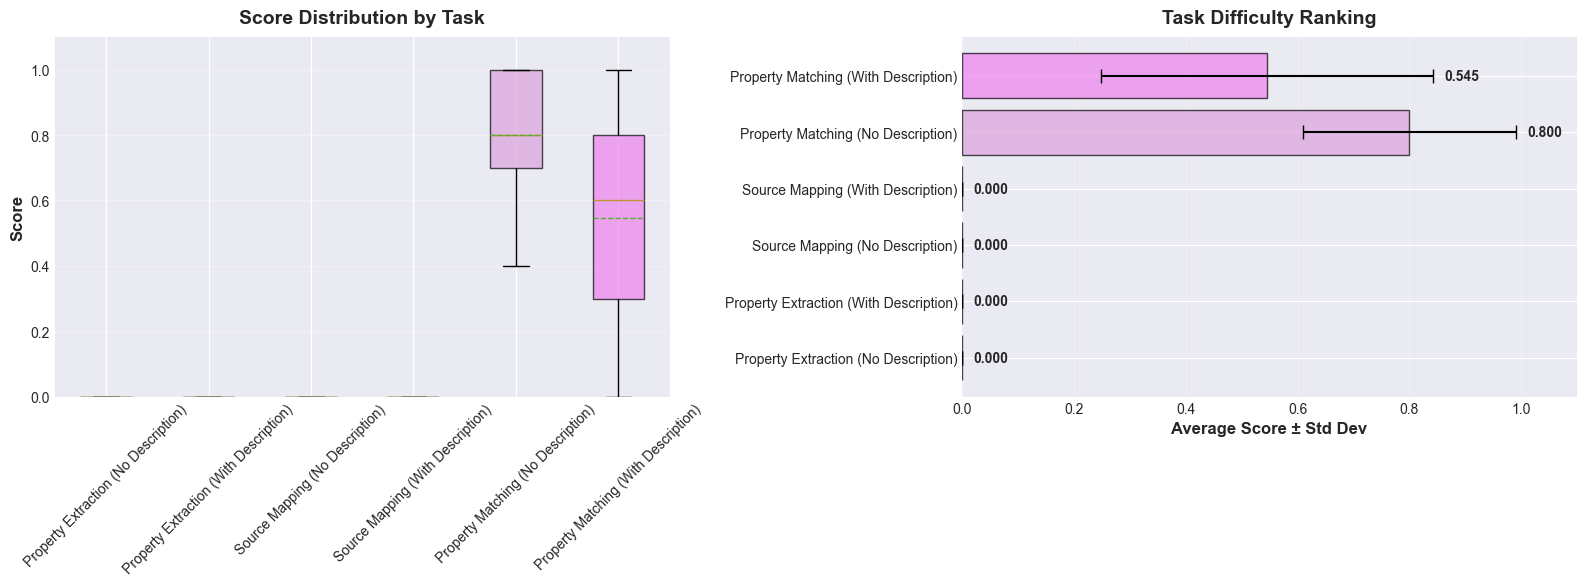

In [ ]:
# ========================================================
# VISUALIZATION 4: Task Difficulty Analysis
# ========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Box plot of scores by task
ax1 = axes[0]
task_data = []
task_labels = []

for task_key in ['1a', '1b', '2a', '2b', '2c', '2d']:
    if task_key in data:
        metric = 'f1_score' if task_key in ['1a', '1b'] else 'accuracy'
        scores = data[task_key][metric].dropna().values
        task_data.append(scores)
        task_labels.append(task_names[task_key].replace('\n', ' '))

bp = ax1.boxplot(task_data, labels=task_labels, patch_artist=True, 
                 showmeans=True, meanline=True)

# Color the boxes
colors = ['#FFB6C1', '#FFE4E1', '#B0E0E6', '#ADD8E6', '#DDA0DD', '#EE82EE']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_ylabel('Score', fontweight='bold', fontsize=12)
ax1.set_title('Score Distribution by Task', fontweight='bold', fontsize=14, pad=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 1.1)

# Right plot: Average scores with error bars
ax2 = axes[1]
task_means = [np.mean(scores) for scores in task_data]
task_stds = [np.std(scores) for scores in task_data]

bars = ax2.barh(range(len(task_labels)), task_means, xerr=task_stds, 
                color=colors, alpha=0.7, edgecolor='black', capsize=5)

ax2.set_yticks(range(len(task_labels)))
ax2.set_yticklabels(task_labels)
ax2.set_xlabel('Average Score ± Std Dev', fontweight='bold', fontsize=12)
ax2.set_title('Task Difficulty Ranking', fontweight='bold', fontsize=14, pad=10)
ax2.set_xlim(0, 1.1)
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (mean, std) in enumerate(zip(task_means, task_stds)):
    ax2.text(mean + std + 0.02, i, f'{mean:.3f}', 
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(results_dir / 'viz_4_task_difficulty.png', dpi=300, bbox_inches='tight')
plt.show()

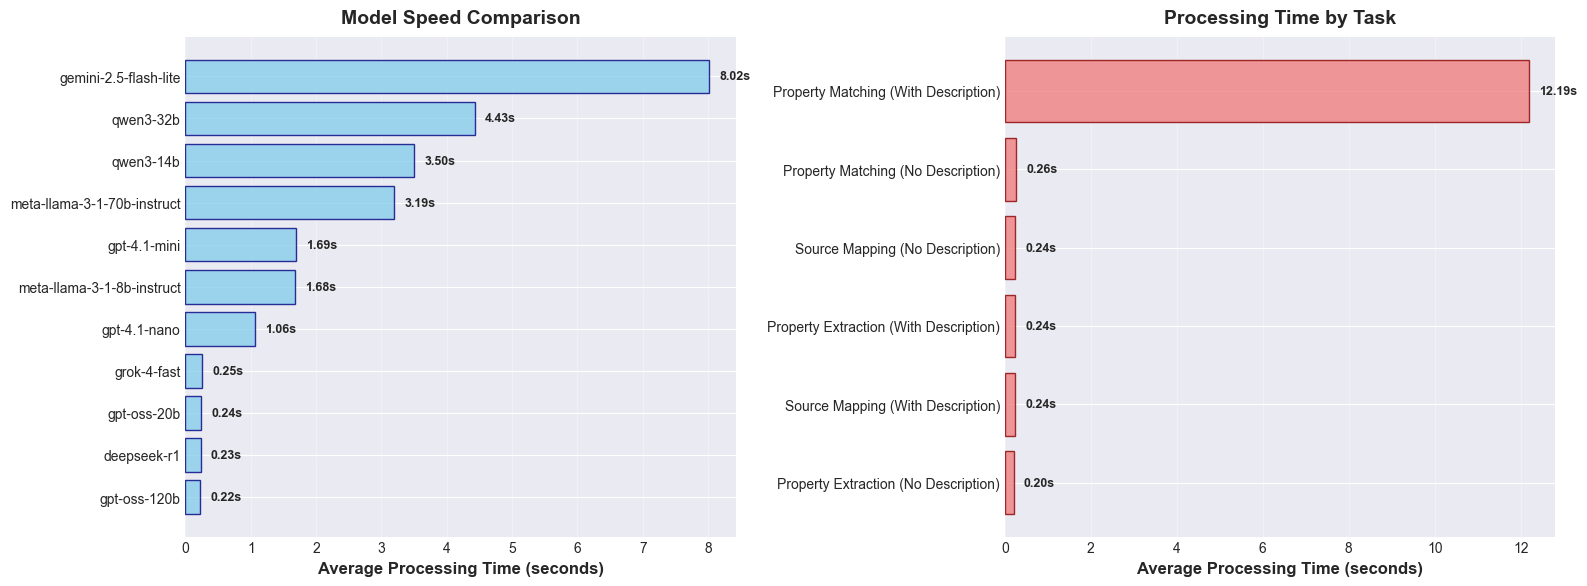

In [ ]:
# ========================================================
# VISUALIZATION 5: Processing Time Analysis
# ========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Average time by model
ax1 = axes[0]
model_times = {}

for task_key, df in data.items():
    if 'elapsed_time' in df.columns:
        for model in df['model'].unique():
            if model not in model_times:
                model_times[model] = []
            times = df[df['model'] == model]['elapsed_time'].dropna().values
            model_times[model].extend(times)

model_avg_times = {model: np.mean(times) for model, times in model_times.items()}
sorted_models = sorted(model_avg_times.items(), key=lambda x: x[1])

models = [m[0] for m in sorted_models]
times = [m[1] for m in sorted_models]

bars = ax1.barh(range(len(models)), times, color='skyblue', alpha=0.8, edgecolor='navy')
ax1.set_yticks(range(len(models)))
ax1.set_yticklabels(models)
ax1.set_xlabel('Average Processing Time (seconds)', fontweight='bold', fontsize=12)
ax1.set_title('Model Speed Comparison', fontweight='bold', fontsize=14, pad=10)
ax1.grid(axis='x', alpha=0.3)

# Add time labels
for i, time_val in enumerate(times):
    ax1.text(time_val + max(times)*0.02, i, f'{time_val:.2f}s', 
            va='center', fontweight='bold', fontsize=9)

# Right: Time by task
ax2 = axes[1]
task_times = {}

for task_key, df in data.items():
    if 'elapsed_time' in df.columns:
        task_times[task_names[task_key].replace('\n', ' ')] = df['elapsed_time'].dropna().mean()

if task_times:
    sorted_tasks = sorted(task_times.items(), key=lambda x: x[1])
    tasks = [t[0] for t in sorted_tasks]
    times = [t[1] for t in sorted_tasks]
    
    bars = ax2.barh(range(len(tasks)), times, color='lightcoral', alpha=0.8, edgecolor='darkred')
    ax2.set_yticks(range(len(tasks)))
    ax2.set_yticklabels(tasks)
    ax2.set_xlabel('Average Processing Time (seconds)', fontweight='bold', fontsize=12)
    ax2.set_title('Processing Time by Task', fontweight='bold', fontsize=14, pad=10)
    ax2.grid(axis='x', alpha=0.3)
    
    for i, time_val in enumerate(times):
        ax2.text(time_val + max(times)*0.02, i, f'{time_val:.2f}s', 
                va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(results_dir / 'viz_5_processing_time.png', dpi=300, bbox_inches='tight')
plt.show()

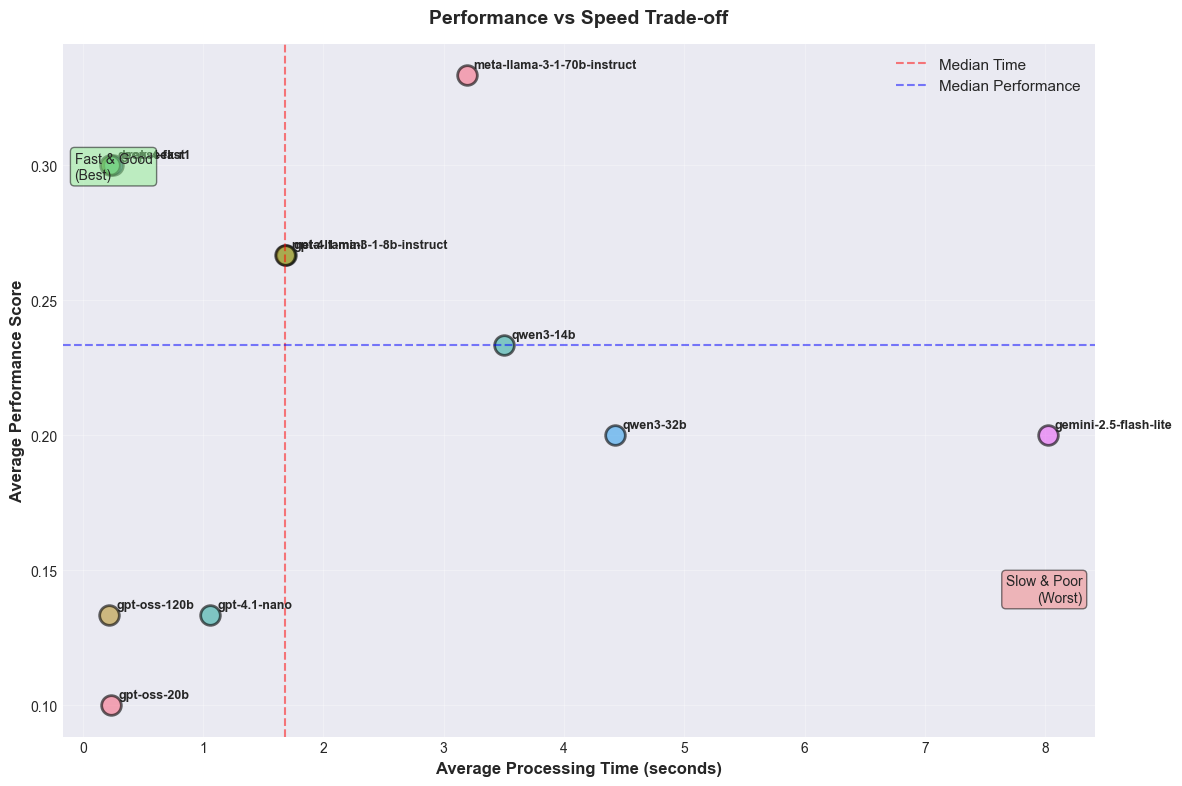

In [ ]:
# ========================================================
# VISUALIZATION 6: Performance vs Time Trade-off
# ========================================================

fig, ax = plt.subplots(figsize=(12, 8))

model_performance = {}
model_time = {}

for task_key, df in data.items():
    metric = 'f1_score' if task_key in ['1a', '1b'] else 'accuracy'
    
    for model in df['model'].unique():
        model_df = df[df['model'] == model]
        
        if model not in model_performance:
            model_performance[model] = []
            model_time[model] = []
        
        model_performance[model].append(model_df[metric].mean())
        if 'elapsed_time' in model_df.columns:
            model_time[model].append(model_df['elapsed_time'].mean())

# Calculate averages
model_avg_perf = {m: np.mean(scores) for m, scores in model_performance.items()}
model_avg_time = {m: np.mean(times) for m, times in model_time.items() if times}

# Plot scatter
for model in model_avg_perf.keys():
    if model in model_avg_time:
        ax.scatter(model_avg_time[model], model_avg_perf[model], 
                  s=200, alpha=0.6, edgecolors='black', linewidth=2)
        ax.annotate(model, 
                   (model_avg_time[model], model_avg_perf[model]),
                   xytext=(5, 5), textcoords='offset points', 
                   fontsize=9, fontweight='bold')

ax.set_xlabel('Average Processing Time (seconds)', fontweight='bold', fontsize=12)
ax.set_ylabel('Average Performance Score', fontweight='bold', fontsize=12)
ax.set_title('Performance vs Speed Trade-off', fontweight='bold', fontsize=14, pad=15)
ax.grid(True, alpha=0.3)

# Add quadrant lines
if model_avg_time and model_avg_perf:
    median_time = np.median(list(model_avg_time.values()))
    median_perf = np.median(list(model_avg_perf.values()))
    
    ax.axvline(median_time, color='red', linestyle='--', alpha=0.5, label='Median Time')
    ax.axhline(median_perf, color='blue', linestyle='--', alpha=0.5, label='Median Performance')
    
    # Add quadrant labels
    ax.text(ax.get_xlim()[0] + 0.1, ax.get_ylim()[1] - 0.05, 
           'Fast & Good\n(Best)', ha='left', fontsize=10, 
           bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    ax.text(ax.get_xlim()[1] - 0.1, ax.get_ylim()[0] + 0.05, 
           'Slow & Poor\n(Worst)', ha='right', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

ax.legend()
plt.tight_layout()
plt.savefig(results_dir / 'viz_6_performance_vs_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

# ========================================================
# SUMMARY STATISTICS TABLE
# ========================================================

print("\n" + "="*80)
print("📊 SUMMARY STATISTICS")
print("="*80)

summary_data = []

for task_key in ['1a', '1b', '2a', '2b', '2c', '2d']:
    if task_key in data:
        df = data[task_key]
        metric = 'f1_score' if task_key in ['1a', '1b'] else 'accuracy'
        
        summary_data.append({
            'Task': task_names[task_key].replace('\n', ' '),
            'Metric': metric,
            'Mean': f"{df[metric].mean():.3f}",
            'Std': f"{df[metric].std():.3f}",
            'Min': f"{df[metric].min():.3f}",
            'Max': f"{df[metric].max():.3f}",
            'Best Model': df.groupby('model')[metric].mean().idxmax(),
            'Worst Model': df.groupby('model')[metric].mean().idxmin(),
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("✅ All visualizations saved to:", results_dir)
print("="*80)


📊 SUMMARY STATISTICS
                                  Task   Metric  Mean   Std   Min   Max                  Best Model  Worst Model
  Property Extraction (No Description) f1_score 0.000 0.000 0.000 0.000                 deepseek-r1  deepseek-r1
Property Extraction (With Description) f1_score 0.000 0.000 0.000 0.000                 deepseek-r1  deepseek-r1
       Source Mapping (No Description) accuracy 0.000 0.000 0.000 0.000                 deepseek-r1  deepseek-r1
     Source Mapping (With Description) accuracy 0.000 0.000 0.000 0.000                 deepseek-r1  deepseek-r1
    Property Matching (No Description) accuracy 0.800 0.200 0.400 1.000                 deepseek-r1  gpt-oss-20b
  Property Matching (With Description) accuracy 0.545 0.311 0.000 1.000 meta-llama-3-1-70b-instruct gpt-4.1-nano

✅ All visualizations saved to: results
